In [1]:
import sys
from pathlib import Path

# Add repository root to Python path
repo_root = Path().absolute().parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import ROOT
import matplotlib.pyplot as plt
import numpy as np
import os
import uproot
import awkward as ak
from tqdm import tqdm


/global/homes/g/gregork/.conda/envs/omni/lib/python3.12/site-packages/ROOT/__init__.py:5: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(
/global/homes/g/gregork/.conda/envs/omni/lib/python3.12/site-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /global/homes/g/gregork/.conda/envs/omni/include/site/python3.12); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "


In [2]:
from src.dataset.preprocessing import get_dense, get_muons, get_photons

PLAYLIST_DIR = Path("/pscratch/sd/g/gregork/MINERvA/raw_data/MediumEnergy_FHC_StandardMC_Playlist/1A")
root_files = sorted(PLAYLIST_DIR.glob("*.root"))[:1]
print(f"Found {len(root_files)} ROOT files")

PRONG_KEYS = [
    "prong_part_pos", "prong_part_E", "prong_part_score",
    "prong_part_mass", "prong_part_charge", "prong_part_pid",
    "prong_dEdXMean",
]
CHARGED_PION_PIDS = {8, 9}  # Geant3 codes for pi+, pi-

twogamma_inv_mass = []
twogamma_no_pion_prong = []  # parallel boolean: True = no charged-pion prong

for root_file in tqdm(root_files, desc="Processing"):
    with uproot.open(root_file) as uf:
        tree = uf["MasterAnaDev"]
        muons = get_muons(tree)
        photons = get_photons(tree)
        n_photons_per_event = photons.n
        n_muons_per_event = muons.n
        prongs = get_dense(PRONG_KEYS, tree)
        all_pids = prongs.data[:, -2].astype(int) # PID column
        is_pion = np.isin(all_pids, list(CHARGED_PION_PIDS))
        n_events = len(prongs.n)
        no_pion_prong = np.ones(n_events, dtype=bool)
        photon_mass_sq = np.zeros(n_events, dtype=float)
        for ev in range(n_events):
            if n_photons_per_event[ev] != 2:
                continue
            start, end = prongs.bounds[ev], prongs.bounds[ev + 1]
            start_photons, end_photons = photons.bounds[ev], photons.bounds[ev + 1]
            if np.any(is_pion[start:end]):
                no_pion_prong[ev] = False
            photons_E = photons.data[start_photons:end_photons, 3]
            photons_pxyz = photons.data[start_photons:end_photons, :3]
            photons_pxyz_total = np.sum(photons_pxyz, axis=0)
            photons_p_mag = np.linalg.norm(photons_pxyz_total)
            photon_mass_sq[ev] = np.sum(photons_E)**2 - photons_p_mag**2
        sel = (n_muons_per_event == 1) & (n_photons_per_event == 2)
        twogamma_inv_mass.append(np.sqrt(np.maximum(photon_mass_sq[sel], 0)))
        twogamma_no_pion_prong.append(no_pion_prong[sel])

twogamma_inv_mass = np.concatenate(twogamma_inv_mass)
twogamma_no_pion_prong = np.concatenate(twogamma_no_pion_prong)

print(f"Selected {len(twogamma_inv_mass)} events with reco muon + 2 photons")
print(f"  of which {twogamma_no_pion_prong.sum()} have no charged-pion prong")


Found 1 ROOT files


Processing: 100%|██████████| 1/1 [00:16<00:00, 16.30s/it]

Selected 20891 events with reco muon + 2 photons
  of which 9191 have no charged-pion prong


In [6]:
a = tree["blob_recoil_E"].array()[:5]
b = tree["blob_recoil_E_ecal"].array()[:5]
c = tree["blob_recoil_E_tracker"].array()[:5]
d = tree["blob_recoil_E_hcal"].array()[:5]
e = tree["blob_recoil_E_nucl"].array()[:5]
f = tree["blob_recoil_E_od"].array()[:5]

In [8]:
b+c+d+e+f, a

(<Array [5e+03, 695, 392, 2.75e+03, 194] type='5 * float64'>,
 <Array [5e+03, 695, 392, 2.75e+03, 194] type='5 * float64'>)

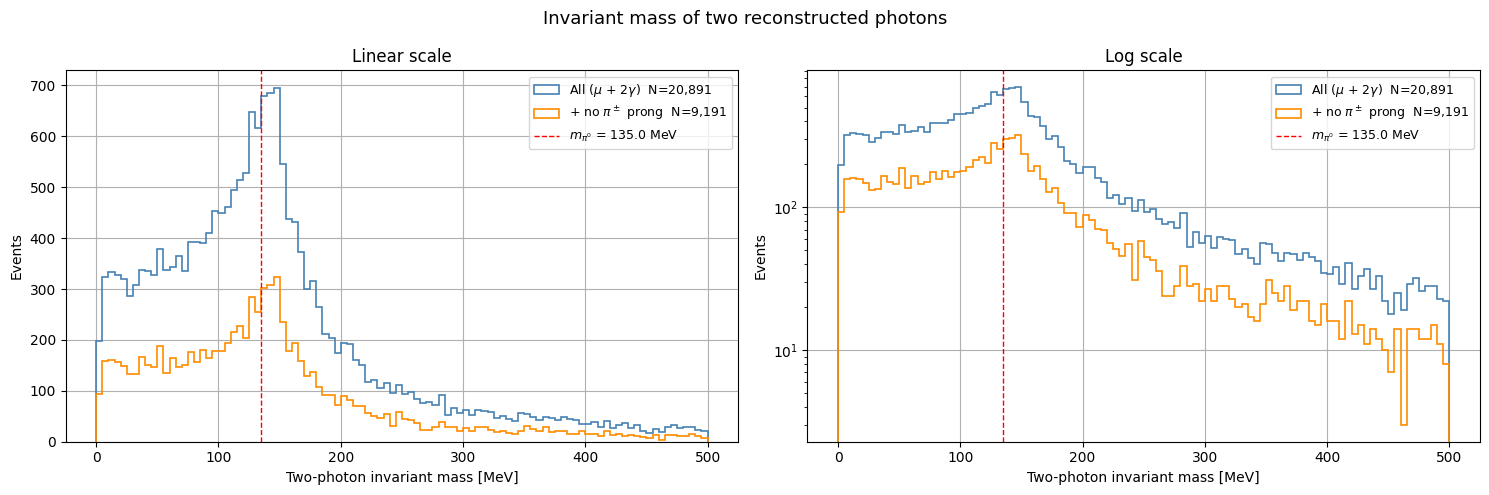

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bins = np.linspace(0, 500, 101)
m_all = twogamma_inv_mass
m_nopi = twogamma_inv_mass[twogamma_no_pion_prong]

for ax in axes:
    ax.hist(m_all, bins=bins, histtype="step", color="steelblue", linewidth=1.2,
            label=rf"All ($\mu$ + 2$\gamma$)  N={len(m_all):,}")
    ax.hist(m_nopi, bins=bins, histtype="step", color="darkorange", linewidth=1.2,
            label=rf"+ no $\pi^\pm$ prong  N={len(m_nopi):,}")
    ax.axvline(134.977, color="red", linestyle="--", linewidth=1, label=r"$m_{\pi^0}$ = 135.0 MeV")
    ax.set_xlabel("Two-photon invariant mass [MeV]")
    ax.set_ylabel("Events")
    ax.legend(fontsize=9)
    ax.grid(True)

axes[0].set_title("Linear scale")
axes[1].set_title("Log scale")
axes[1].set_yscale("log")

fig.suptitle(r"Invariant mass of two reconstructed photons", fontsize=13)
fig.tight_layout()
fig.show()

In [5]:
for key in tree.keys():
    #if "verte" in key.lower() and "prong" in key.lower(): print(key)
    if "michel" in key.lower():
        print(key)


improved_nmichel
truth_improved_michel_electron
FittedMichel_michel_fitPass_sz
FittedMichel_michel_fitPass
FittedMichel_michel_isoverlay_sz
FittedMichel_michel_isoverlay
FittedMichel_reco_michel_index_sz
FittedMichel_reco_michel_index
FittedMichel_reco_true_michel_index_sz
FittedMichel_reco_true_michel_index
has_michel_primary_particle_PDG_sz
has_michel_primary_particle_PDG
has_michel_primary_particle_trackID_sz
has_michel_primary_particle_trackID
improved_michel_in_vertex_point_sz
improved_michel_in_vertex_point
improved_michel_match_vec_sz
improved_michel_match_vec
improved_michel_matched_pdg_sz
improved_michel_matched_pdg
improved_michel_matched_primary_pdg_sz
improved_michel_matched_primary_pdg
improved_michel_ndigits_sz
improved_michel_ndigits
improved_michel_vertex_type_sz
improved_michel_vertex_type
improved_michel_view_vec_sz
improved_michel_view_vec
matched_michel_avg_idx
matched_michel_code
matched_michel_end_idx
matched_michel_end_module1
matched_michel_end_module2
matched_m